In [1]:
import geopandas as gpd
import networkx as nx
import numpy as np

from geopy.distance import geodesic
from scipy.spatial import KDTree
import folium

In [ ]:
file_path = "../data/raw/OGIM_v1.1.gpkg"

pipelines = gpd.read_file(file_path, layer="Oil_Natural_Gas_Pipelines")

wells = gpd.read_file(file_path, layer="Oil_and_Natural_Gas_Wells")

refineries = gpd.read_file(file_path, layer="Crude_Oil_Refineries")

In [ ]:
print(len(pipelines), len(wells), len(refineries))

1740970 2560399 712


In [ ]:
sample_size = 260000

pipelines_sample = pipelines.sample(n=sample_size, random_state=42)

In [ ]:
wells["coords"] = wells.geometry.apply(lambda x: (x.x, x.y))
refineries["coords"] = refineries.geometry.apply(lambda x: (x.x, x.y))

In [ ]:
G = nx.Graph()

for _, row in pipelines_sample.iterrows():

    geom = row.geometry

    if geom.geom_type == "LineString":

        coords = list(geom.coords)

        for i in range(len(coords)-1):

            start = coords[i]
            end = coords[i+1]

            dist = geodesic(
                (start[1], start[0]),
                (end[1], end[0])
            ).km

            G.add_edge(start, end, weight=dist)

    elif geom.geom_type == "MultiLineString":

        for line in geom.geoms:

            coords = list(line.coords)

            for i in range(len(coords)-1):

                start = coords[i]
                end = coords[i+1]

                dist = geodesic(
                    (start[1], start[0]),
                    (end[1], end[0])
                ).km

                G.add_edge(start, end, weight=dist)

In [ ]:
largest = max(nx.connected_components(G), key=len)

G_main = G.subgraph(largest).copy()

print("Nodes:", len(G_main.nodes))
print("Edges:", len(G_main.edges))

Nodes: 77346
Edges: 77345


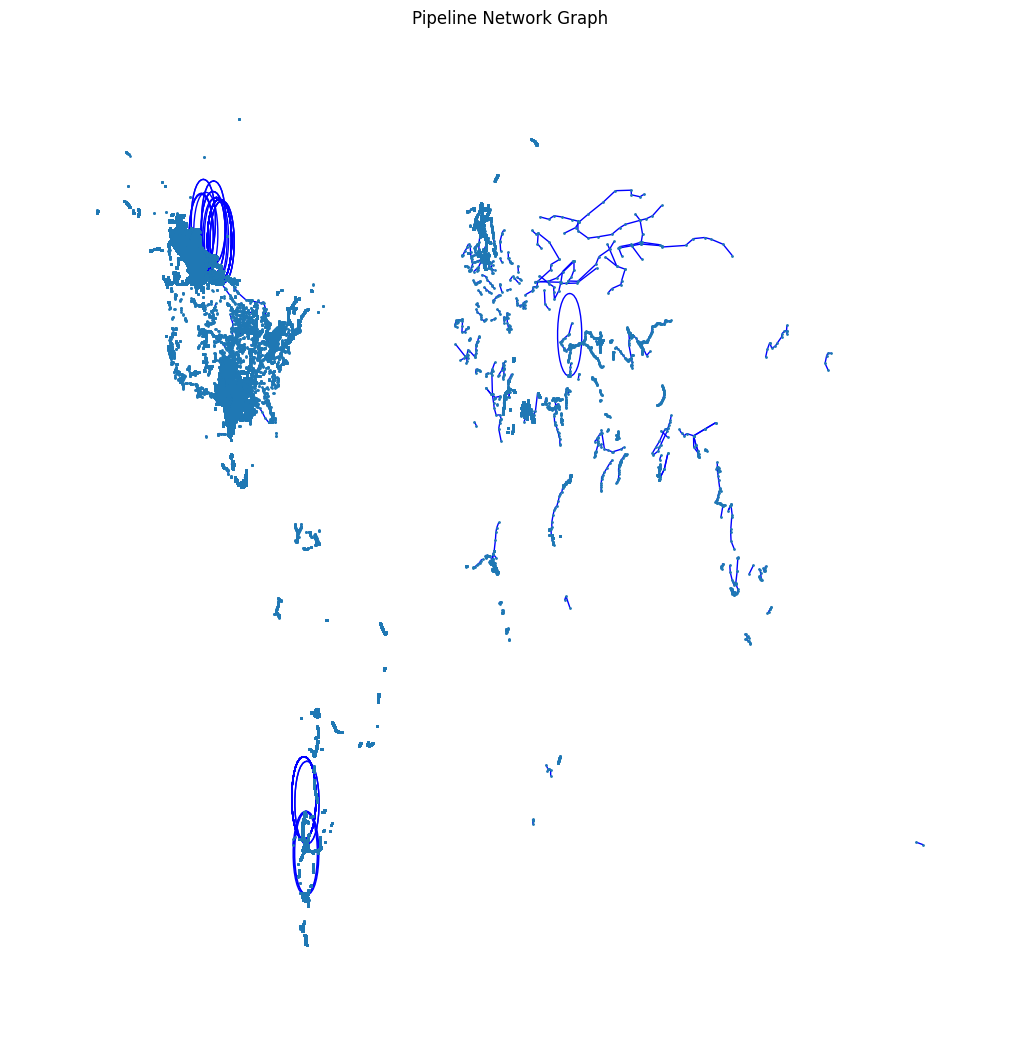

In [ ]:
import matplotlib.pyplot as plt

pos = {node: node for node in G.nodes}

plt.figure(figsize=(10,10))
nx.draw(G, pos, node_size=1, edge_color="blue")
plt.title("Pipeline Network Graph")
plt.show()

In [ ]:
nodes = list(G_main.nodes)

node_array = np.array(nodes)

tree = KDTree(node_array)

In [ ]:
def nearest_pipeline_node(location):

    dist, idx = tree.query(location)

    return tuple(node_array[idx])

In [ ]:
def nearest_well(refinery_location):

    min_dist = float("inf")
    best = None

    for w in wells["coords"]:

        d = geodesic(
            (refinery_location[1], refinery_location[0]),
            (w[1], w[0])
        ).km

        if d < min_dist:
            min_dist = d
            best = w

    return best

In [ ]:
def optimize_transport(refinery_location):

    well = nearest_well(refinery_location)

    start_node = nearest_pipeline_node(well)

    end_node = nearest_pipeline_node(refinery_location)

    if not nx.has_path(G_main, start_node, end_node):

        return None, well, None, None

    route = nx.shortest_path(G_main, start_node, end_node, weight="weight")

    distance = nx.shortest_path_length(G_main, start_node, end_node, weight="weight")

    cost = distance * 2.8   # example tariff

    return route, well, distance, cost

In [ ]:
refinery_location = (28.610026, 77.389351)

route, well, distance, cost = optimize_transport(refinery_location)

print("Nearest well:", well)
print("Pipeline distance:", distance)
print("Cost:", cost)
print("Route nodes:", len(route))

Nearest well: (30.49925, 78.68214)
Pipeline distance: 0
Cost: 0.0
Route nodes: 1


In [ ]:
import folium

# create map centered at first route point
m = folium.Map(location=[route[0][1], route[0][0]], zoom_start=6)

# convert route to (lat, lon) format
route_latlon = [(node[1], node[0]) for node in route]

# draw route line
folium.PolyLine(
    route_latlon,
    color="blue",
    weight=4,
    opacity=0.8
).add_to(m)

# optional: show route points
for node in route:
    folium.CircleMarker(
        location=[node[1], node[0]],
        radius=2,
        color="red"
    ).add_to(m)


folium.Marker(route_latlon[0], popup="Start", icon=folium.Icon(color="green")).add_to(m)
folium.Marker(route_latlon[-1], popup="End", icon=folium.Icon(color="red")).add_to(m)
m


In [ ]:
A* cluster 

(np.float64(-97.70905212374291), np.float64(27.15459440618854))


In [ ]:
(lat, lon)

NameError: name 'lat' is not defined

In [ ]:
ai agent sanity 